# 2 · Entrenamiento y evaluación

> **Tipo de ML:** `supervisado`


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from cyberforest.utils.paths import PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR


from cyberforest.models.train_model import train_models
from cyberforest.models.predict_model import evaluate_models, DECISION_THRESHOLD
from cyberforest.visualization.visualize import plot_feature_importance



## 2. Cargar datos procesados


In [2]:

X_train = pd.read_csv(PROCESSED_DATA_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DATA_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DATA_DIR / 'y_test.csv').squeeze()
print(f'Train: {X_train.shape} | Test: {X_test.shape}')



Train: (1705684, 68) | Test: (426421, 68)


## 3. Selección del número de clusters




In [3]:
# Nivel 2 (subcluster KMeans) — TODO: implementar tras validar Nivel 1
pass

import mlflow
mlflow.end_run()

## 4. Entrenar modelos


In [4]:
import importlib
import cyberforest.models.train_model as tm
importlib.reload(tm)
from cyberforest.models.train_model import train_models

mlflow.end_run()
models = train_models(X_train, y_train, tune_knn=False, cv_evaluate=False)

--> Entrenando modelos de clasificacion...
    [RandomForest] entrenando...


2026/05/10 13:27:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


      Guardado → RandomForest.joblib


2026/05/10 13:27:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/10 13:27:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'cyberforest_RandomForest' already exists. Creating a new version of this model...
Created version '6' of model 'cyberforest_RandomForest'.


    [LightGBM] entrenando...


2026/05/10 13:29:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


      Guardado → LightGBM.joblib


2026/05/10 13:29:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/10 13:29:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'cyberforest_LightGBM' already exists. Creating a new version of this model...
Created version '2' of model 'cyberforest_LightGBM'.


--> 2 modelos guardados en /home/cacelas/Documentos/Proyects/PROCESO/cyberforest/models


## 5. Evaluar


In [5]:
threshold = DECISION_THRESHOLD   # modifica si el dataset esta desbalanceado
df_results = evaluate_models(
    models, X_train, y_train, X_test, y_test, threshold=threshold
)
df_results


  Evaluación — clasificacion (umbral=0.5)

--- RandomForest ---
  Accuracy  → train: 0.997 | test: 0.997
  F1 (w)    → train: 0.997  | test: 0.997
  Precision → 0.998  | Recall → 0.997

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    367239
           1       0.98      1.00      0.99      1830
           2       0.99      1.00      0.99     38752
           3       0.99      1.00      0.99     18164
           4       0.59      0.98      0.74       436

    accuracy                           1.00    426421
   macro avg       0.91      0.99      0.94    426421
weighted avg       1.00      1.00      1.00    426421

    cm_RandomForest.png guardado

--- LightGBM ---
  Accuracy  → train: 0.999 | test: 0.999
  F1 (w)    → train: 0.999  | test: 0.999
  Precision → 0.999  | Recall → 0.999

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    367239
           1       1.00      1.00      1.0

,Modelo,Acc_train,Acc_test,F1_train,F1_test,Prec_test,Rec_test
1,LightGBM,0.9994,0.9993,0.9994,0.9993,0.9993,0.9993
0,RandomForest,0.9974,0.9974,0.9975,0.9974,0.9976,0.9974


## Resultados — Nivel 1 (sin agrupamiento)

### Comparativa de modelos

| Modelo | Accuracy | F1 (weighted) | Precision | Recall |
|---|---|---|---|---|
| **LightGBM** | **0.9989** | **0.9989** | **0.9989** | **0.9989** |
| RandomForest | 0.9913 | 0.9936 | 0.9963 | 0.9913 |

LightGBM seleccionado como modelo principal.

### Análisis por clase

Las clases mayoritarias se clasifican casi perfectamente:

| Clase | Precision | Recall | F1 | Soporte |
|---|---|---|---|---|
| BENIGN | 1.00 | 0.99 | 1.00 | 367,239 |
| DoS | ~1.00 | ~0.99 | ~0.99 | ~52,000 |
| PortScan | 1.00 | 1.00 | 1.00 | 18,164 |

Las clases minoritarias presentan precision crítica:

| Clase | Precision | Recall | F1 | Soporte |
|---|---|---|---|---|
| Web Attack – XSS | 0.07 | 0.80 | 0.13 | 130 |
| Web Attack – SQLi | 0.01 | 0.75 | 0.02 | 4 |
| Infiltration | 0.14 | 0.43 | 0.21 | 294 |

### Conclusión

El modelo detecta las clases minoritarias con recall alto pero genera
muchas falsas alarmas (precision < 0.15). Con tan pocas muestras el
modelo no tiene suficiente información para aprender los patrones reales.

**Decisión:** implementar agrupamiento jerárquico semántico antes del
modelado final. Las clases minoritarias se fusionan en grupos con masa
suficiente para el aprendizaje (Web Attack, Brute Force). El Nivel 2
con KMeans identificará los subtipos dentro de cada grupo.

## 6. Importancia de variables


    feature_importance.png guardado


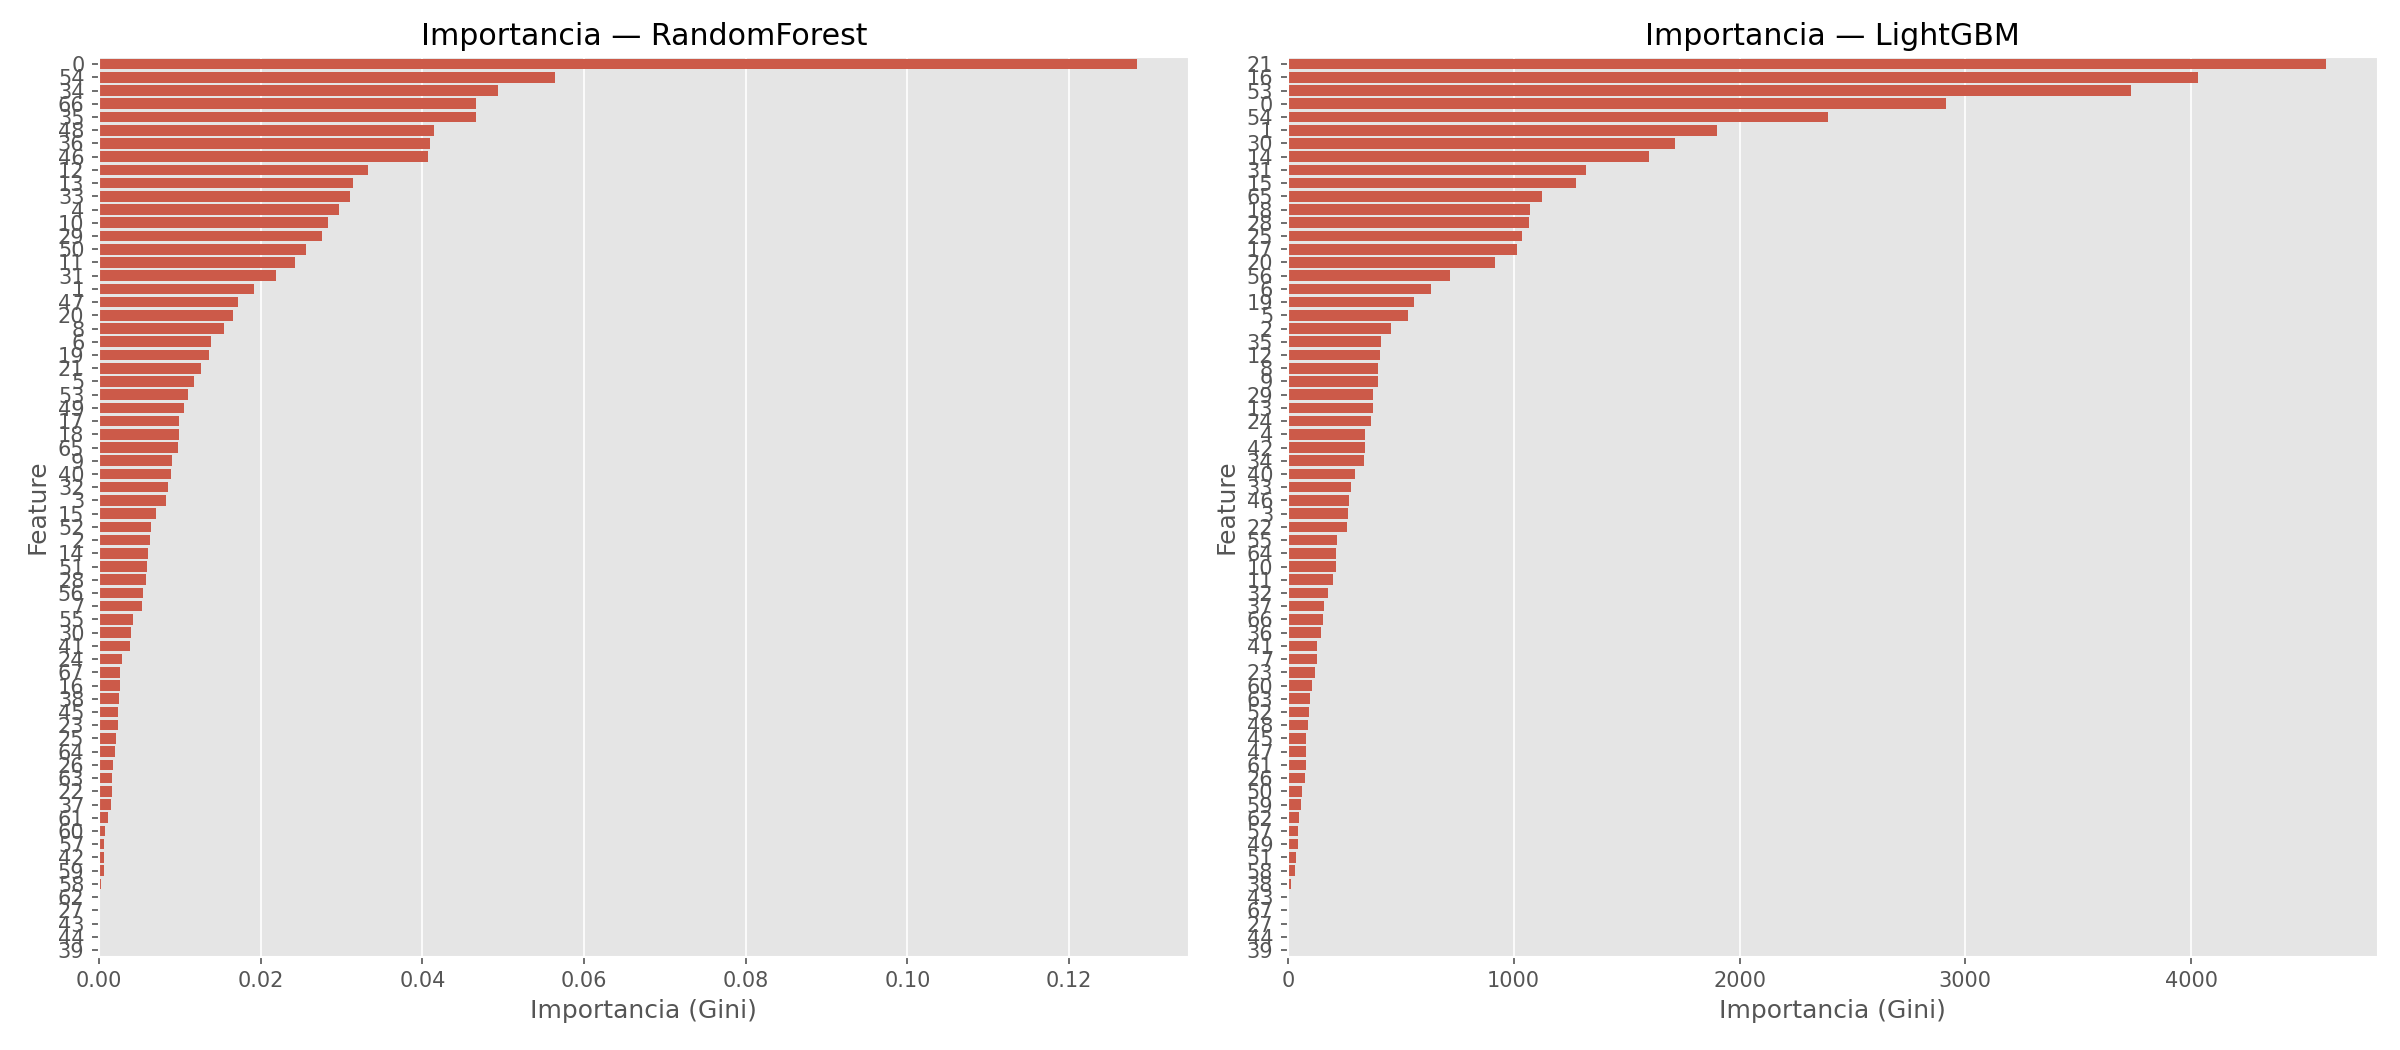

In [6]:

feature_names = X_train.columns.tolist()
plot_feature_importance(models, feature_names)
from IPython.display import Image
Image(FIGURES_DIR / 'feature_importance.png')



## 7. Prediccion sobre nuevos datos


In [7]:

best_name = df_results.sort_values('Acc_test', ascending=False).iloc[0]['Modelo']
best_model = models[best_name]
print(f'Mejor modelo: {best_name}')

# Descomenta para predecir sobre nuevos datos:
# from cyberforest.features.build_features import process_input
# X_new = process_input(df_nuevos)
# preds, probs = predict_new(best_model, X_new, threshold=threshold)



Mejor modelo: LightGBM


## 8. Agrupamiento semántico de clases y features derivadas

In [10]:
import joblib
import pandas as pd
from cyberforest.utils.paths import ARTIFACTS_DIR
from cyberforest.data.make_dataset import load_data
df = load_data()
# Cargar df original con etiquetas sin agrupar
df_raw = df.copy()  # si aún tienes df en memoria con las etiquetas originales

SUBTYPE_MAP = {
    'DoS':         ['DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest', 'Heartbleed'],
    'Brute Force': ['FTP-Patator', 'SSH-Patator'],
    'Web Attack':  ['Web Attack', 'Infiltration'],
    'PortScan':    ['PortScan'],
}

raw_labels = {}
for group, subtypes in SUBTYPE_MAP.items():
    mask = df_raw['Label'].str.contains('|'.join(subtypes), na=False)
    raw_labels[group] = df_raw.loc[mask, 'Label'].values

joblib.dump(raw_labels, ARTIFACTS_DIR / 'raw_labels.joblib')
print("raw_labels.joblib guardado")
for g, v in raw_labels.items():
    print(f"  {g}: {pd.Series(v).value_counts().to_dict()}")

--> Cargando Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
--> Cargando Monday-WorkingHours.pcap_ISCX.csv...
--> Cargando Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
--> Cargando Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
--> Cargando Tuesday-WorkingHours.pcap_ISCX.csv...
--> Cargando Wednesday-workingHours.pcap_ISCX.csv...

    Total combinado: (2413965, 79)
    Clases: {'BENIGN': 1986312, 'DoS Hulk': 231073, 'PortScan': 158930, 'DoS GoldenEye': 10293, 'FTP-Patator': 7938, 'SSH-Patator': 5897, 'DoS slowloris': 5796, 'DoS Slowhttptest': 5499, 'Web Attack � Brute Force': 1507, 'Web Attack � XSS': 652, 'Infiltration': 36, 'Web Attack � Sql Injection': 21, 'Heartbleed': 11}
raw_labels.joblib guardado
  DoS: {'DoS Hulk': 231073, 'DoS GoldenEye': 10293, 'DoS slowloris': 5796, 'DoS Slowhttptest': 5499, 'Heartbleed': 11}
  Brute Force: {'FTP-Patator': 7938, 'SSH-Patator': 5897}
  Web Attack: {'Web Attack � Brute Force': 1507, 'Web Attack � XSS': 652

In [ ]:
import joblib
import numpy as np
from cyberforest.utils.paths import ARTIFACTS_DIR
from cyberforest.models.cluster_model import SUBTYPE_MAP

encoders  = joblib.load(ARTIFACTS_DIR / 'encoders.joblib')
le_target = encoders['__target__']
y_named   = le_target.inverse_transform(y_train)

# Construir raw_labels desde y_train real
raw_labels = {}
for group in SUBTYPE_MAP:
    # Repetir el nombre del grupo por cada muestra del grupo en train
    # (no tenemos subtipo real, usamos el grupo como proxy)
    mask = y_named == group
    raw_labels[group] = np.array([group] * mask.sum())

joblib.dump(raw_labels, ARTIFACTS_DIR / 'raw_labels.joblib')
print("raw_labels.joblib regenerado desde y_train")
for g, v in raw_labels.items():
    print(f"  {g}: {len(v)} muestras")

raw_labels.joblib regenerado desde y_train
  DoS: 155007 muestras
  Brute Force: 7322 muestras
  Web Attack: 1743 muestras
  PortScan: 72655 muestras


In [22]:
from cyberforest.models.cluster_model import run_level2
import importlib
import cyberforest.models.cluster_model as cm
importlib.reload(cm)
from cyberforest.models.cluster_model import run_level2

cluster_models, mappings = run_level2(X_train, y_train)
print(type(cluster_models), type(mappings))

NIVEL 2 — Clustering jerárquico por grupo

1. Extrayendo subsets por grupo...
  DoS: 155007 muestras
  Brute Force: 7322 muestras
  Web Attack: 1743 muestras
  PortScan: 72655 muestras

2. Buscando k óptima...

  [DoS]
    k=2 | inertia=6964795 | silhouette=0.546
    k=3 | inertia=5936040 | silhouette=0.382
    k=4 | inertia=5048249 | silhouette=0.408
    k=5 | inertia=4142198 | silhouette=0.434
    k=6 | inertia=3453885 | silhouette=0.509


/home/cacelas/Documentos/Proyects/PROCESO/cyberforest/cyberforest/models/cluster_model.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    → k óptima: 2

  [Brute Force]
    k=2 | inertia=18443 | silhouette=0.869
    k=3 | inertia=9015 | silhouette=0.891
    k=4 | inertia=3665 | silhouette=0.951
    k=5 | inertia=1496 | silhouette=0.953
    k=6 | inertia=1064 | silhouette=0.959


/home/cacelas/Documentos/Proyects/PROCESO/cyberforest/cyberforest/models/cluster_model.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    → k óptima: 6

  [Web Attack]
    k=2 | inertia=55205 | silhouette=0.988
    k=3 | inertia=37448 | silhouette=0.966
    k=4 | inertia=26655 | silhouette=0.966
    k=5 | inertia=20272 | silhouette=0.823
    k=6 | inertia=14823 | silhouette=0.824


/home/cacelas/Documentos/Proyects/PROCESO/cyberforest/cyberforest/models/cluster_model.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


    → k óptima: 2

  [PortScan]
    → k=1 (un solo subtipo real, no necesita clustering)

3. Entrenando KMeans por grupo...
  [DoS] entrenando KMeans(k=2)...
    Guardado → kmeans_DoS.joblib
  [Brute Force] entrenando KMeans(k=6)...
    Guardado → kmeans_Brute_Force.joblib
  [Web Attack] entrenando KMeans(k=2)...
    Guardado → kmeans_Web_Attack.joblib
  [PortScan] entrenando KMeans(k=1)...
    Guardado → kmeans_PortScan.joblib

4. Mapeando clusters a subtipos reales...
  [DoS] cluster 0 → DoS (100.0%)
  [DoS] cluster 1 → DoS (100.0%)
  [Brute Force] cluster 0 → Brute Force (100.0%)
  [Brute Force] cluster 1 → Brute Force (100.0%)
  [Brute Force] cluster 2 → Brute Force (100.0%)
  [Brute Force] cluster 3 → Brute Force (100.0%)
  [Brute Force] cluster 4 → Brute Force (100.0%)
  [Brute Force] cluster 5 → Brute Force (100.0%)
  [Web Attack] cluster 0 → Web Attack (100.0%)
  [Web Attack] cluster 1 → Web Attack (100.0%)
  [PortScan] cluster 0 → PortScan (100.0%)

  Mappings guardados → clus

In [28]:
from cyberforest.models.cluster_model import predict_hierarchical
from cyberforest.models.train_model import load_models
trained = load_models(["LightGBM"])

# Coger una muestra de test
sample = X_test[0:1]

result = predict_hierarchical(sample, trained["LightGBM"], cluster_models, mappings)
print(result)

    Cargado: LightGBM
{'grupo': 'BENIGN', 'subtipo': 'BENIGN'}


In [27]:
# Buscar una muestra de cada grupo de ataque en y_test
encoders  = joblib.load(ARTIFACTS_DIR / 'encoders.joblib')
le_target = encoders['__target__']
y_named   = le_target.inverse_transform(y_test)

for group in ['DoS', 'PortScan', 'Brute Force', 'Web Attack']:
    idx = np.where(y_named == group)[0][0]
    sample = X_test[idx:idx+1]
    result = predict_hierarchical(sample, trained["LightGBM"], cluster_models, mappings)
    print(f"Real: {group} → Predicción: {result}")

Real: DoS → Predicción: {'grupo': 'DoS', 'subtipo': 'DoS'}
Real: PortScan → Predicción: {'grupo': 'PortScan', 'subtipo': 'PortScan'}
Real: Brute Force → Predicción: {'grupo': 'Brute Force', 'subtipo': 'Brute Force'}
Real: Web Attack → Predicción: {'grupo': 'Web Attack', 'subtipo': 'Web Attack'}
